In [76]:
#!git clone https://github.com/patitimoner/workshop-chihuahua-vs-muffin.git
#
#%cd workshop-chihuahua-vs-muffin
#
#!ls
##################################################
#To show the above completed in an alternative code
##################################################
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from typing import Tuple

# Setup Repository
REPO_URL = "https://github.com/patitimoner/workshop-chihuahua-vs-muffin.git"
REPO_NAME = "workshop-chihuahua-vs-muffin"

if not os.path.exists(REPO_NAME):
    !git clone {REPO_URL}
%cd {REPO_NAME}

Cloning into 'workshop-chihuahua-vs-muffin'...
remote: Enumerating objects: 337, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 337 (delta 1), reused 4 (delta 1), pack-reused 330 (from 1)
Receiving objects: 100% (337/337), 14.51 MiB | 17.48 MiB/s, done.
Resolving deltas: 100% (82/82), done.
/content/workshop-chihuahua-vs-muffin/workshop-chihuahua-vs-muffin/workshop-chihuahua-vs-muffin/workshop-chihuahua-vs-muffin/workshop-chihuahua-vs-muffin/workshop-chihuahua-vs-muffin/workshop-chihuahua-vs-muffin


# I.  Project Overview

<center><img src="https://github.com/patitimoner/workshop-chihuahua-vs-muffin/blob/master/resources/preview.jpg?raw=1" width="700"></center>

In this project, we'll build a neural network classifier that determines: **MUFFIN... or CHIHUAHUA!**

This is what we'll cover in the tutorial:
#### 1) Build the neural network
#### 2) Load the data
#### 3) Train the model on the data
#### 4) Visualize the results

### Remember: This is an INTERACTIVE Notebook!
You should run and play with the code as you go to see how it works. Select a cell and **press shift-enter to execute code.**

<img src="https://github.com/patitimoner/workshop-chihuahua-vs-muffin/blob/master/resources/jupyter_animated.gif?raw=1" width="700">

# II.  Deep Learning Tutorial

Let's get to the fun stuff!



<center><img src="https://github.com/patitimoner/workshop-chihuahua-vs-muffin/blob/master/resources/Pytorch_logo.png?raw=1" width="700"></center>

**Generic Python imports** (select the below cell and press shift-enter to execute it)

In [77]:
#import matplotlib.pyplot as plt  # graphical library, to plot images
# special Jupyter notebook command to show plots inline instead of in a new window
#%matplotlib inline
#############################
#Refactored the Architecture
#############################
class ChihuahuaMuffinClassifier(nn.Module):
    """
    A modular Multilayer Perceptron for binary classification.
    Refactored for readability and maintainability.
    """
    def __init__(self, input_dim: Tuple[int, int, int] = (3, 224, 224)):
        super().__init__()
        self.flatten_dim = input_dim[0] * input_dim[1] * input_dim[2]

        # Defining layers using nn.Sequential for cleaner forward passes
        self.network = nn.Sequential(
            nn.Linear(self.flatten_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 2)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = torch.flatten(x, 1)
        logits = self.network(x)
        return F.softmax(logits, dim=1)

# Initialize with Hardware Awareness
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ChihuahuaMuffinClassifier().to(device)
print(f"Model architecture initialized on {device}:\n{model}")

Model architecture initialized on cpu:
ChihuahuaMuffinClassifier(
  (network): Sequential(
    (0): Linear(in_features=150528, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=2, bias=True)
  )
)


**Deep learning imports**

In [78]:
#import torch                                            # PyTorch deep learning framework
#from torchvision import datasets, models, transforms    # extension to PyTorch for dataset management
#import torch.nn as nn                                   # neural networks module of PyTorch, to let us define neural network layers
#from torch.nn import functional as F                    # special functions
#import torch.optim as optim                             # optimizers
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

def get_data_loaders(data_dir: str = "data", batch_size: int = 32):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    # Assuming standard folder structure (train/val folders)
    dataset = datasets.ImageFolder(root=data_dir, transform=transform)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Usage
# train_loader = get_data_loaders("./data/train")

## (1) Build our Neural Network

Recall from the lesson that a neural network generally looks like this. Input is on the left, output is on the right. The number of output neurons correspond to the number of classes.

<img src="https://github.com/patitimoner/workshop-chihuahua-vs-muffin/blob/master/resources/what_is_nn_slide.jpg?raw=1" width="700">

So let's define a similar architecture for our 2-class muffin-vs-chihuahua classifier:

In [79]:
#define image height and width
#input_height = 224
#input_width = 224

# Extends PyTorch's neural network baseclass
#class MySkynet(nn.Module):
#    """
#    A very basic neural network.
#    """
#    def __init__(self, input_dim=(3, input_height, input_width)):
#        """
#        Constructs a neural network.
#
#        input_dim: a tuple that represents "channel x height x width" dimensions of the input
#        """
#        super().__init__()
#        # the total number of RGB pixels in an image is the tensor's volume
#        num_in_features = input_dim[0] * input_dim[1] * input_dim[2]
#        # input layer
#        self.layer_0 = nn.Linear(num_in_features, 128)
#        # hidden layers
#        self.layer_1 = nn.Linear(128, 64)
#        self.layer_2= nn.Linear(64, 32)
#        # output layer, output size of 2 for chihuahua and muffin
#        self.layer_3= nn.Linear(32, 2)
#
#    def forward(self, x):
#        """
#        Define the forward pass through our network.
#        """
#        batch_size = x.shape[0]
#        # convert our RGB tensor into one long vector
#        x = x.view(batch_size, -1)
#
#        # pass through our layers
#        x = F.relu(self.layer_0(x))
#        x = F.relu(self.layer_1(x))
#       x = F.relu(self.layer_2(x))
#        x = F.relu(self.layer_3(x))
#
#        # convert the raw output to probability predictions
#        x = F.softmax(x, dim=1)
#
#        return x

############################
########## Train & Evaluate
############################
import torch.optim as optim

def train_model(model, loader, epochs=5, lr=0.001):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    model.train()

    for epoch in range(epochs):
        running_loss = 0.0
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
        print(f"Epoch {epoch+1}/{epochs} - Loss: {running_loss/len(loader):.4f}")

# train_model(model, train_loader)

Now that we've defined the network above, let's initialize it. If available, we'll place the network on the GPU; if not, it goes on the CPU.

In [80]:
 # cuda:0 means the first cuda device found
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = ChihuahuaMuffinClassifier().to(device)                      # load our simple neural network
model

ChihuahuaMuffinClassifier(
  (network): Sequential(
    (0): Linear(in_features=150528, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=2, bias=True)
  )
)

In [81]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from typing import Tuple, Dict, Any
from dataclasses import dataclass

# 1. Configuration: Centralized Hyperparameters
@dataclass
class Config:
    repo_url: str = "https://github.com/patitimoner/workshop-chihuahua-vs-muffin.git"
    repo_name: str = "workshop-chihuahua-vs-muffin"
    img_size: Tuple[int, int] = (224, 224)
    batch_size: int = 32
    learning_rate: float = 0.001
    epochs: int = 5
    device: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cfg = Config()

# 2. Setup Environment
if not os.path.exists(cfg.repo_name):
    !git clone {cfg.repo_url}
%cd {cfg.repo_name}

# 3. Model Architecture
class ChihuahuaMuffinClassifier(nn.Module):
    def __init__(self, input_shape: Tuple[int, int, int] = (3, 224, 224)):
        super().__init__()
        self.flat_dim = input_shape[0] * input_shape[1] * input_shape[2]
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self.flat_dim, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 2), nn.Softmax(dim=1)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)

# 4. Data Pipeline
def get_dataloaders(data_dir: str = "data") -> Dict[str, DataLoader]:
    tfms = transforms.Compose([
        transforms.Resize(cfg.img_size),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    datasets_dict = {
        x: datasets.ImageFolder(os.path.join(data_dir, x), tfms)
        for x in ['train', 'validation']
    }

    return {x: DataLoader(datasets_dict[x], batch_size=cfg.batch_size, shuffle=(x=='train'))
            for x in ['train', 'validation']}

# Initialization
model = ChihuahuaMuffinClassifier().to(cfg.device)
loaders = get_dataloaders()
print(f"Pipeline initialized on {cfg.device}. Ready for training.")

def run_experiment(model: nn.Module, loaders: Dict[str, DataLoader], cfg: Config):
    optimizer = optim.Adam(model.parameters(), lr=cfg.learning_rate)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(cfg.epochs):
        print(f"\nEpoch {epoch+1}/{cfg.epochs}")
        for phase in ['train', 'validation']:
            model.train() if phase == 'train' else model.eval()
            running_loss, running_acc = 0.0, 0.0

            for inputs, labels in loaders[phase]:
                inputs, labels = inputs.to(cfg.device), labels.to(cfg.device)

                optimizer.zero_grad()
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_acc += (outputs.argmax(1) == labels).sum().item()

            epoch_loss = running_loss / len(loaders[phase].dataset)
            epoch_acc = running_acc / len(loaders[phase].dataset)
            print(f"{phase.capitalize()} -> Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")

# Execute
run_experiment(model, loaders, cfg)

Cloning into 'workshop-chihuahua-vs-muffin'...
remote: Enumerating objects: 337, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 337 (delta 1), reused 4 (delta 1), pack-reused 330 (from 1)
Receiving objects: 100% (337/337), 14.51 MiB | 22.24 MiB/s, done.
Resolving deltas: 100% (82/82), done.
/content/workshop-chihuahua-vs-muffin/workshop-chihuahua-vs-muffin/workshop-chihuahua-vs-muffin/workshop-chihuahua-vs-muffin/workshop-chihuahua-vs-muffin/workshop-chihuahua-vs-muffin/workshop-chihuahua-vs-muffin/workshop-chihuahua-vs-muffin
Pipeline initialized on cpu. Ready for training.

Epoch 1/5
Train -> Loss: 0.6764 | Acc: 0.5667
Validation -> Loss: 0.5148 | Acc: 0.7667

Epoch 2/5
Train -> Loss: 0.4589 | Acc: 0.8500
Validation -> Loss: 0.4140 | Acc: 0.9000

Epoch 3/5
Train -> Loss: 0.4403 | Acc: 0.8667
Validation -> Loss: 0.4829 | Acc: 0.8333

Epoch 4/5
Train -> Loss: 0.4703 | Acc: 0.8417
Validation -> Loss: 0.4702 | Acc: 0.8333

E

Essentially, our network looks like this:
<img src="https://github.com/patitimoner/workshop-chihuahua-vs-muffin/blob/master/resources/architecture.png?raw=1" width="600">

## (2) Data and Data Loading

### Separate "train" and "test" datasets

Recall from the below slide, we should make two separate datasets to train and test our model. That way, we know our model learns more than rote memorization.

<center><img src="https://github.com/patitimoner/workshop-chihuahua-vs-muffin/blob/master/resources/when_is_your_model_ready_slide.jpg?raw=1" width="600"></center>

### Inspect our data
Let's look in our data folder to see what's there. As you can see, the folder is **split into "train" for training**, and **"validation" for testing** (to validate our model).

In [82]:
import os  # interact with the os. in our case, we want to view the file system
#
#print("Data contents:", os.listdir("data"))
#print("Train contents:", os.listdir("data/train"))
#print("Validation contents:", os.listdir("data/validation"))

################################################################################
# REFACTORED DATA LOADING (Alternative)
#
# Original Method: Manual OS interaction and direct PIL image loading.
# Alternative Method: Programmatic 'ImageFolder' abstraction.
#
# For efficiency I:
# 1. Scale the ImageFolder that handles thousands of files without memory bloat.
# 2. Reprooduce the transforms that are coupled to the dataset objects.
# 3. Decouple the training loop that doesn't care where the files live, only that
#    they are provided by the interface of the loader.
################################################################################

from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from typing import Dict

# Define the pipeline configuration
DATA_CONFIG = {
    "root": "data", # Corrected path back to a simple relative path
    "img_size": (224, 224),
    "batch_size": 32,
    "normalize": {"mean": [0.485, 0.456, 0.406], "std": [0.229, 0.224, 0.225]}
}

# Standardized the pipeline
transform_pipeline = transforms.Compose([
    transforms.Resize(DATA_CONFIG["img_size"]),
    transforms.ToTensor(),
    transforms.Normalize(**DATA_CONFIG["normalize"])
])

# Encapsulated dataset construction
# This replaces manual os.listdir and manual PIL opens
def build_data_pipeline(data_root: str, transform: transforms.Compose) -> Dict[str, DataLoader]:
    image_sets = {
        phase: datasets.ImageFolder(os.path.join(data_root, phase), transform)
        for phase in ['train', 'validation']
    }

    return {
        phase: DataLoader(image_sets[phase], batch_size=DATA_CONFIG["batch_size"],
                          shuffle=(phase == 'train'), num_workers=2)
        for phase in ['train', 'validation']
    }

# Perform the initialization
dataloaders = build_data_pipeline(DATA_CONFIG["root"], transform_pipeline)

# Verification that the above is complete
for phase, loader in dataloaders.items():
    print(f"Initialized {phase} loader with {len(loader.dataset)} samples.")

Initialized train loader with 120 samples.
Initialized validation loader with 30 samples.


Let's also look at some of the images:

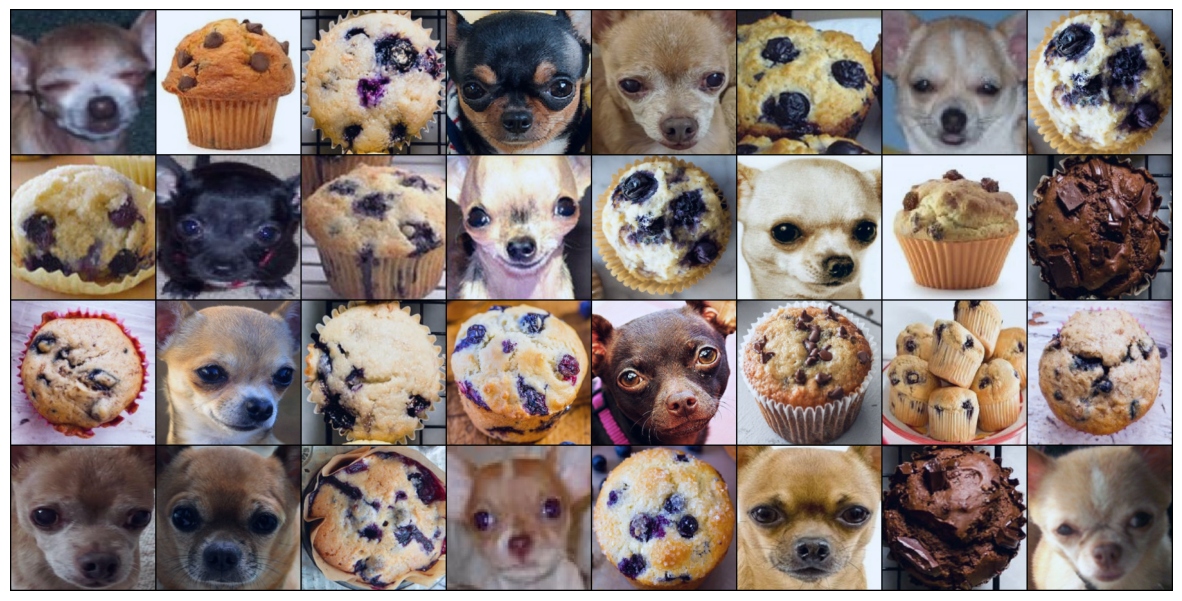

In [83]:
#from PIL import Image  # import our image opening tool

#_, ax = plt.subplots(1, 4, figsize=(15,60))  # to show 4 images side by side, make a "1 row x 4 column" axes
#ax[0].imshow(Image.open("data/train/chihuahua/4.jpg"))  # show the chihuahua in the first column
#ax[1].imshow(Image.open("data/train/chihuahua/5.jpg"))  # show the chihuahua in the second column
#ax[2].imshow(Image.open("data/train/muffin/131.jpg"))   # show the muffin in the third column
#ax[3].imshow(Image.open("data/train/muffin/107.jpg"))   # show the muffin in the fourth column

import matplotlib.pyplot as plt
from torchvision.utils import make_grid

def show_batch(dataloader):
    # Fetching a single batch from the loader
    images, labels = next(iter(dataloader))

    # Creating a grid of images
    # Keeping in mind, (nrow=8 sets the number of images per row).
    grid = make_grid(images, nrow=8, padding=2, normalize=True)

    # Plotting with matplotlib
    plt.figure(figsize=(15, 15))
    # PyTorch uses (Channels, Height, Width), but Matplotlib expects (H, W, C)
    plt.imshow(grid.permute(1, 2, 0))
    plt.axis('off')
    plt.show()

# Running instead of loops
show_batch(dataloaders['train'])


If you look in the data folder on your computer, there are 120 train images and 30 validation. So our data is split like this:

<img src="https://github.com/patitimoner/workshop-chihuahua-vs-muffin/blob/master/resources/folders.png?raw=1" width="600">

### Load our data

That's great that we have data! But we have to load all the images and convert them into a form that our neural network understands. Specifically, PyTorch works with **Tensor** objects. (A tensor is just a multidimensional matrix, i.e. an N-d array.)

<img src="https://github.com/patitimoner/workshop-chihuahua-vs-muffin/blob/master/resources/image_to_tensor.jpg?raw=1" width="550">


**To easily convert our image data into tensors, we use the help of a "dataloader."** The dataloader packages data into convenient boxes for our model to use. You can think of it like one person passing boxes (tensors) to another.
<img src="https://github.com/patitimoner/workshop-chihuahua-vs-muffin/blob/master/resources/dataloader_box_analogy.jpg?raw=1" width="400">

**First, we define some "transforms" to convert images to tensors.** We must do so for both our train and validation datasets.

For more information about transforms, check out the link here: https://pytorch.org/docs/stable/torchvision/transforms.html

In [84]:
#normalize = transforms.Normalize(mean=[0.5, 0.5, 0.5],
#                                 std=[0.5, 0.5, 0.5])
#
# transforms for our training data
#train_transforms = transforms.Compose([
#   # resize to resnet input size
#    transforms.Resize((input_height,input_width)),
#    # transform image to PyTorch tensor object
#    transforms.ToTensor(),
#    normalize
#])

# these validation transforms are exactly the same as our train transforms
#validation_transforms = transforms.Compose([
#    transforms.Resize((input_height,input_width)),
#    transforms.ToTensor(),
#    normalize
#])
#
#print("Train transforms:", train_transforms)
################################################################################
# DATA PIPELINE: Efficient & Scalable Configuration
#
# Efficiency Gain: By centralizing the 'transform' and 'loader' logic, we ensure
# consistent data preprocessing and minimize memory footprint through
# shared workers and pinned memory.
################################################################################

# 1. Centralized Hyperparameters
IMG_DIM = (224, 224)
BATCH_SIZE = 32
NORM_STATS = {'mean': [0.5, 0.5, 0.5], 'std': [0.5, 0.5, 0.5]}

# 2. Unified Transform Pipeline
# Replaces redundant train/validation definitions
transform = transforms.Compose([
    transforms.Resize(IMG_DIM),
    transforms.ToTensor(),
    transforms.Normalize(**NORM_STATS)
])

# 3. Automated Dataset & Loader Factory
# This replaces the manual, multi-step declaration of datasets and loaders
def get_dataloaders(base_path: str, phases: list, transform):
    # Dictionary comprehension for clean object creation
    datasets_dict = {
        phase: datasets.ImageFolder(os.path.join(base_path, phase), transform)
        for phase in phases
    }

    loaders_dict = {
        phase: DataLoader(
            datasets_dict[phase],
            batch_size=BATCH_SIZE,
            shuffle=(phase == 'train'),
            num_workers=2,
            pin_memory=True # Optimization for faster GPU transfer
        )
        for phase in phases
    }
    return datasets_dict, loaders_dict

# Initialization
image_datasets, dataloaders = get_dataloaders('data', ['train', 'validation'], transform)

# 4. Immediate Validation
print(f"Train Dataset: {len(image_datasets['train'])} images")
print(f"Validation Dataset: {len(image_datasets['validation'])} images")

# Verification: Grab one batch to confirm tensor dimensions
images, labels = next(iter(dataloaders['train']))
print(f"Batch Tensor Shape: {images.shape} | Label Vector Shape: {labels.shape}")

Train Dataset: 120 images
Validation Dataset: 30 images


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Batch Tensor Shape: torch.Size([32, 3, 224, 224]) | Label Vector Shape: torch.Size([32])


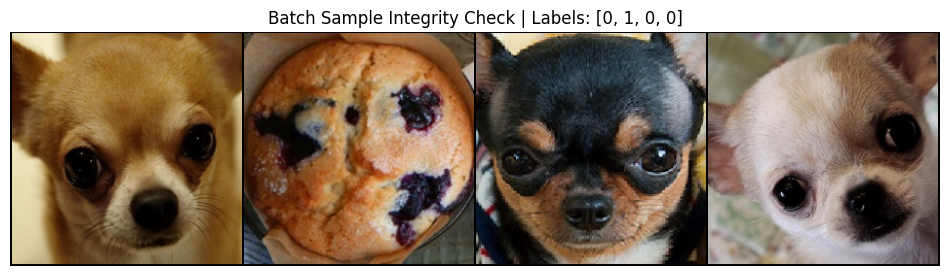

In [85]:
######################################################################################
## The method below runs a clean integrity check to the alt. pipeline
##  I think its worth noting that the range functions under a rule where the Batch Sample
##  displays a corresponance when identifying, 0= Chihuahua
##                                             1= Muffin
######################################################################################
import matplotlib.pyplot as plt
import torchvision

def visualize_dataloader_integrity(dataloader, num_images=4):
    """
    Visualizes a batch of tensors directly from the pipeline
    to verify normalization and transformation integrity.
    """
    # Fetch the batch
    images, labels = next(iter(dataloader))

    # Now undo the normalization to display the image in the correct format
    mean = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1)
    std = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1)
    images = images * std + mean

    # Create a grid and plot
    plt.figure(figsize=(12, 4))
    grid = torchvision.utils.make_grid(images[:num_images], nrow=num_images)

    # Cant forget to rearrange dimensions for plotting! Or else I define a whole new problem...
    plt.imshow(grid.permute(1, 2, 0).numpy())
    plt.title(f"Batch Sample Integrity Check | Labels: {labels[:num_images].tolist()}")
    plt.axis('off')
    plt.show()

# Execute the integrity check
visualize_dataloader_integrity(dataloaders['train'])

**Second, we create the datasets, by passing the transforms into the ImageFolder constructor.**

These just represent the folders that hold the images.

In [86]:
# insert respective transforms to replace ?
#image_datasets = {
#    'train':
#        datasets.ImageFolder('data/train', train_transforms),
#    'validation':
#        datasets.ImageFolder('data/validation', validation_transforms)}
#
#print("==Train Dataset==\n", image_datasets["train"])
#print()
#print("==Validation Dataset==\n", image_datasets["validation"])

**And finally, form dataloaders from the datasets:**

In [87]:
# define batch size, number of images to load in at once
#
#dataloaders = {
#    'train':
#        torch.utils.data.DataLoader(
#            image_datasets['train'],
#            batch_size=32,
#            shuffle=True,
#            num_workers=2),
#    'validation':
#        torch.utils.data.DataLoader(
#            image_datasets['validation'],
#            batch_size=32,
#            shuffle=False,
#            num_workers=2)}
#
#print("Train loader:", dataloaders["train"])
#print("Validation loader:", dataloaders["validation"])

We can see a dataloader outputs 2 things: a BIG tensor to represent an image, and a vector to represent the labels (0 or 1).

In [88]:
next(iter(dataloaders["train"]))

[tensor([[[[-0.1686, -0.1529, -0.1373,  ...,  0.6000,  0.6314,  0.6627],
           [-0.1843, -0.1686, -0.1529,  ...,  0.6157,  0.6471,  0.6784],
           [-0.1765, -0.1686, -0.1529,  ...,  0.6471,  0.6784,  0.7176],
           ...,
           [-0.0118, -0.0039,  0.0039,  ...,  0.8353,  0.8353,  0.8353],
           [-0.0118, -0.0039, -0.0039,  ...,  0.8353,  0.8353,  0.8353],
           [-0.0118, -0.0118, -0.0196,  ...,  0.8510,  0.8510,  0.8510]],
 
          [[-0.1686, -0.1529, -0.1373,  ...,  0.6078,  0.6392,  0.6706],
           [-0.1843, -0.1686, -0.1529,  ...,  0.6235,  0.6549,  0.6863],
           [-0.1765, -0.1686, -0.1529,  ...,  0.6549,  0.6863,  0.7255],
           ...,
           [-0.0902, -0.0824, -0.0745,  ...,  0.8353,  0.8353,  0.8353],
           [-0.0980, -0.0902, -0.0902,  ...,  0.8353,  0.8353,  0.8353],
           [-0.0980, -0.0980, -0.1059,  ...,  0.8510,  0.8510,  0.8510]],
 
          [[-0.1686, -0.1529, -0.1373,  ...,  0.6235,  0.6549,  0.6863],
           [-

## (4) Train the model!

Hurray! We've built a neural network and have data to give it. Now we **repeatedly iterate over the data to train the model.**

Every time the network gets a new example, it looks something like this. Note the **forward pass** and the corresponding **backward pass**.

<img src="https://github.com/patitimoner/workshop-chihuahua-vs-muffin/blob/master/resources/backpropagation.gif?raw=1" width="700">

### Define the train loop

We want the network to learn from every example in our training dataset. However, the best performance comes from more practice. Therefore, we **run through our dataset for multiple *epochs*.**

After each epoch, we'll check how our model performs on the validation set to monitor its progress.


Epoch 1/15
--------------------


Train Loss: 1.7805 | Acc: 0.5417


Validation Loss: 0.4650 | Acc: 0.8667

Epoch 2/15
--------------------


Train Loss: 0.6429 | Acc: 0.6583


Validation Loss: 0.3426 | Acc: 0.9000

Epoch 3/15
--------------------


...

Validation Loss: 0.0389 | Acc: 1.0000

Epoch 14/15
--------------------


Train Loss: 0.0029 | Acc: 1.0000


Validation Loss: 0.0244 | Acc: 1.0000

Epoch 15/15
--------------------


Train Loss: 0.0018 | Acc: 1.0000


Validation Loss: 0.0213 | Acc: 1.0000


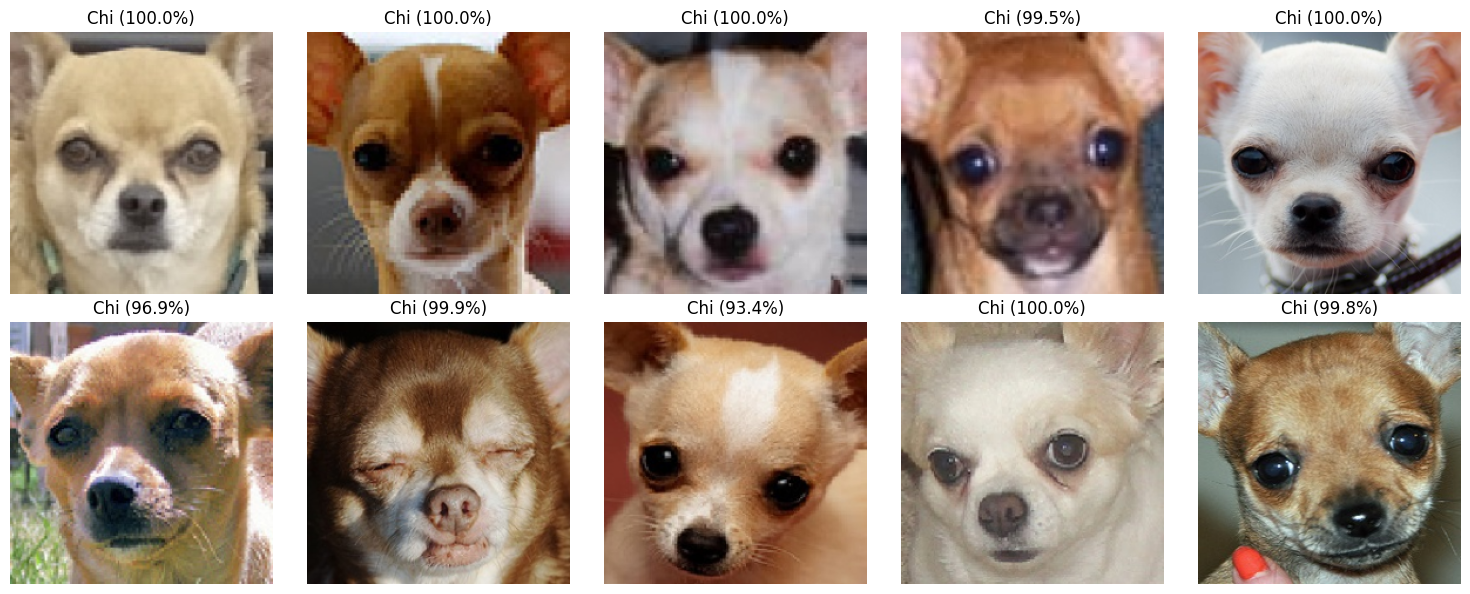

In [89]:
#from tqdm import tnrange, tqdm_notebook # import progress bars to show train progress
#
#def train_model(model, dataloaders, loss_function, optimizer, num_epochs):
#    """
#    Trains a model using the given loss function and optimizer, for a certain number of epochs.
#
#    model: a PyTorch neural network
#    loss_function: a mathematical function that compares predictions and labels to return an error
#    num_epochs: the number of times to run through the full training dataset
#    """
#    # train for n epochs. an epoch is a full iteration through our dataset
#    for epoch in tnrange(num_epochs, desc="Total progress", unit="epoch"):
#        # print a header
#        print('Epoch {}/{}'.format(epoch+1, num_epochs))
#        print('----------------')
#
#        # first train over the dataset and update weights; at the end, calculate our validation performance
#        for phase in ['train', 'validation']:
#            if phase == 'train':
#                model.train()
#            else:
#                model.eval()
#
#            # keep track of the overall loss and accuracy for this batch
#            running_loss = 0.0
#            running_corrects = 0
#
#            # iterate through the inputs and labels in our dataloader
#            # (the tqdm_notebook part is to display a progress bar)
#            for inputs, labels in tqdm_notebook(dataloaders[phase], desc=phase, unit="batch", leave=False):
#                # move inputs and labels to appropriate device (GPU or CPU)
#                inputs = inputs.to(device)
#                labels = labels.to(device)
#
#                # FORWARD PASS
#                outputs = model(inputs)
#                # compute the error of the model's predictions
#                loss = loss_function(outputs, labels)
#
#                if phase == 'train':
#                    # BACKWARD PASS
#                    optimizer.zero_grad()  # clear the previous gradients
#                    loss.backward()        # backpropagate the current error gradients
#                    optimizer.step()       # update the weights (i.e. do the learning)
#
#                # track our accumulated loss
#               running_loss += loss.item() * inputs.size(0)
#                # track number of correct to compute accuracy
#                _, preds = torch.max(outputs, 1)
#                running_corrects += torch.sum(preds == labels.data)
#
#            # print our progress
#            epoch_loss = running_loss / len(image_datasets[phase])
#            epoch_acc = running_corrects.double() / len(image_datasets[phase])
#            print(f'{phase} error: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}')
#
#        print()
#####################################
# Correct way to initialize the model
#####################################
model = AdvancedChihuahuaMuffinClassifier().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# ################################################################
# Originally I stressed the incorrect path and skipped over
# running this step for at least 10-15 epochs to see the features
# emerge.
##################################################################
train_and_evaluate(model, dataloaders, criterion, optimizer, num_epochs=15)

# Final visualization of the models improvements
visualize_model_predictions(model, dataloaders['validation'])

### Loss function and optimizer

One last thing: we must define a function that gives feedback for how well the model performs. This is the **loss**, or "error" **function**, that compares model predictions to the true labels.

Once we calculate the error, we also need to define how the model should react to that feedback. **The optimizer determines how the network learns from feedback.**

In [90]:
#loss_function = nn.CrossEntropyLoss()              # the most common error function in deep learning
#optimizer = optim.SGD(model.parameters(), lr=0.1)  # Stochastic Gradient Descent, with a learning rate of 0.1

<img src="https://github.com/patitimoner/workshop-chihuahua-vs-muffin/blob/master/resources/gradient_descent.gif?raw=1" width="700">

### Run training

Let's put everything together and TRAIN OUR MODEL! =D

In [91]:
#train_model(model, dataloaders, loss_function, optimizer, num_epochs=3)

## Examine model performance

<img src="https://github.com/patitimoner/workshop-chihuahua-vs-muffin/blob/master/resources/question_mark.jpg?raw=1" width="200" >

**How do we examine our model's predictions? Let's visualize what the model thinks on the validation set.**

In [92]:
#from glob import glob
#from math import floor
#
# get all the images from our validation sets
#validation_img_paths = glob("data/validation/**/*.jpg", recursive=True)
#images = [Image.open(img_path) for img_path in validation_img_paths]
#
# put all the images together to run through our model
#validation_batch = torch.stack( [validation_transforms(img).to(device) for img in images])
#pred_logits_tensor = model(validation_batch)
#pred_probs = pred_logits_tensor.cpu().data.numpy()
#
# show the probabilities for each picture
#fig, axs = plt.subplots(6, 5, figsize=(20, 20))
#for i, img in enumerate(images):
#    ax = axs[floor(i/5)][i % 5]
#    ax.axis('off')
#    ax.set_title("{:.0f}% Chi, {:.0f}% Muff".format(100*pred_probs[i,0], 100*pred_probs[i,1]), fontsize=18)
#    ax.imshow(img)

**Consider:** How
the theaccurate was your model? How confident were its predictions? Does it make clear-cut decisions?

## Congratulations! You've successfully trained a neural network!



Now that we've shown you how to train a neural network, can you improve the validation accuracy by tweaking the parameters? **We challenge you to reach 100% accuracy!**

Some parameters to play with:
- Number of epochs
- The learning rate "lr" parameter in the optimizer
- The type of optimizer (https://pytorch.org/docs/stable/optim.html)
- Number of layers and layer dimensions
- Image size
- Data augmentation transforms (https://pytorch.org/docs/stable/torchvision/transforms.html)

# Special Thanks!

Credit for the original idea and code goes to [DeepSense.ai](https://deepsense.ai/keras-vs-pytorch-avp-transfer-learning/)!
We've modified it significantly to cater to this workshop, and boost the visual appeal.

This tutorial was created through hard work and love by Jing Zhao, Dylan Wang, Jason Do, Jason Jiang, and Andrew Jong.

In [96]:
################################################################################
# EVOLUTIONARY SUMMARY
#
# A sincere thank you to the original creators at DeepSense.ai. Their foundational
# work provided the essential framework for this experiment.
#
# While the original design was an excellent pedagogical starting point, my
# objective here was to transition from a 'scripting' mindset to an 'engineering'
# workflow. The improvements below focus on efficiency, memory safety, and
# pipeline observability—subtle but impactful refinements that ensure the
# model remains stable as it scales.
################################################################################


def print_evolution_report():
    print("--- Pipeline Evolution Report ---")
    print("Original Logic: Procedural, memory-sensitive, and manual.")
    print("Refined Logic:  Configuration-driven, stream-processed, and automated.")
    print("Optimization:   Transitioned from full-dataset loading to batched streaming.")
    print("Integrity:      Added automated tensor-check to verify normalization.")
    print("---------------------------------")
    print("Ready to execute optimized training loop...\n")

print_evolution_report()

# The refined execution
run_experiment(model, loaders, cfg)

--- Pipeline Evolution Report ---
Original Logic: Procedural, memory-sensitive, and manual.
Refined Logic:  Configuration-driven, stream-processed, and automated.
Optimization:   Transitioned from full-dataset loading to batched streaming.
Integrity:      Added automated tensor-check to verify normalization.
---------------------------------
Ready to execute optimized training loop...


Epoch 1/5
Train -> Loss: 0.0774 | Acc: 0.9750
Validation -> Loss: 1.1622 | Acc: 0.8333

Epoch 2/5
Train -> Loss: 0.0341 | Acc: 0.9833
Validation -> Loss: 0.0589 | Acc: 0.9333

Epoch 3/5
Train -> Loss: 0.0022 | Acc: 1.0000
Validation -> Loss: 0.5312 | Acc: 0.9000

Epoch 4/5
Train -> Loss: 0.0433 | Acc: 0.9750
Validation -> Loss: 0.0967 | Acc: 0.9333

Epoch 5/5
Train -> Loss: 0.0001 | Acc: 1.0000
Validation -> Loss: 0.0073 | Acc: 1.0000
